In [1]:
# Install
!pip install wordcloud -q

import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(" Libraries loaded!")


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


 Libraries loaded!


In [2]:
# Load data
df = pd.read_csv('C:/Users/Riyad/projects/fake_news/step4_balanced.csv')
df['text'] = df['headline'].fillna('') + ' ' + df['content'].fillna('')
df = df.dropna(subset=['text', 'label'])

# Split by class
authentic_text = ' '.join(df[df['label'] == 'authentic']['text'].values)
fake_text = ' '.join(df[df['label'] == 'fake']['text'].values)
ai_fake_text = ' '.join(df[df['label'] == 'ai_fake']['text'].values)

print(" Data loaded!")
print(f"Authentic: {len(df[df['label']=='authentic'])} rows")
print(f"Fake: {len(df[df['label']=='fake'])} rows")
print(f"AI Fake: {len(df[df['label']=='ai_fake'])} rows")

 Data loaded!
Authentic: 5000 rows
Fake: 5000 rows
AI Fake: 5000 rows


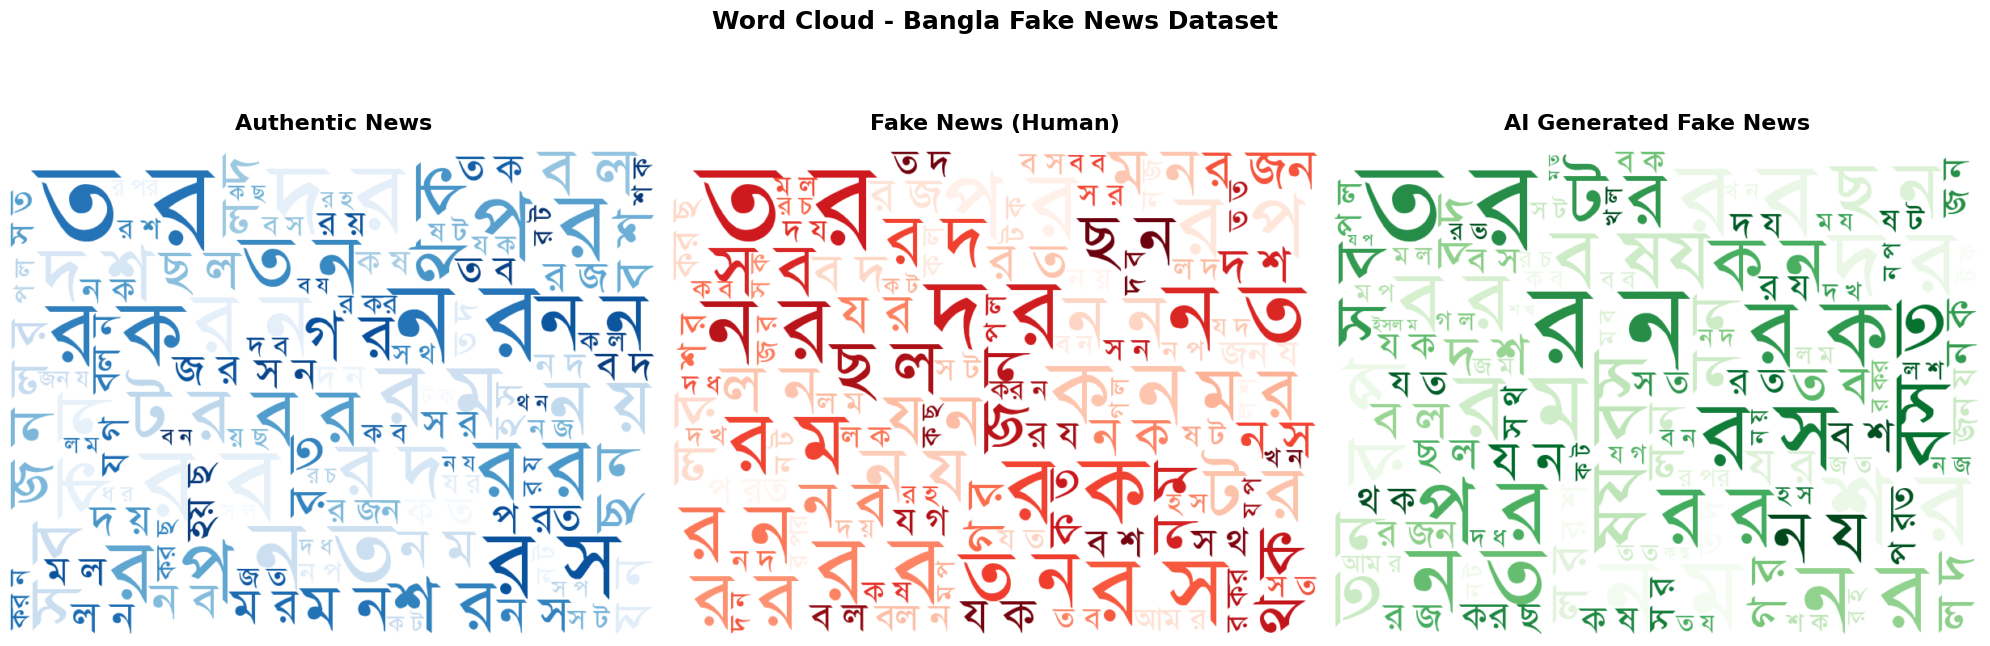

 Word Cloud saved!


In [5]:
# Generate Word Clouds with Bangla font
font_path = "C:/Users/Riyad/projects/fake_news/SolaimanLipi.ttf"

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

configs = [
    (authentic_text, 'Authentic News', 'Blues', axes[0]),
    (fake_text, 'Fake News (Human)', 'Reds', axes[1]),
    (ai_fake_text, 'AI Generated Fake News', 'Greens', axes[2]),
]

for text, title, cmap, ax in configs:
    wc = WordCloud(
        font_path=font_path,
        width=800,
        height=600,
        background_color='white',
        colormap=cmap,
        max_words=100,
        min_font_size=10,
        max_font_size=150,
        random_state=42
    ).generate(text)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.axis('off')

plt.suptitle('Word Cloud - Bangla Fake News Dataset', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(
    'C:/Users/Riyad/projects/fake_news/word_cloud.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
print(" Word Cloud saved!")

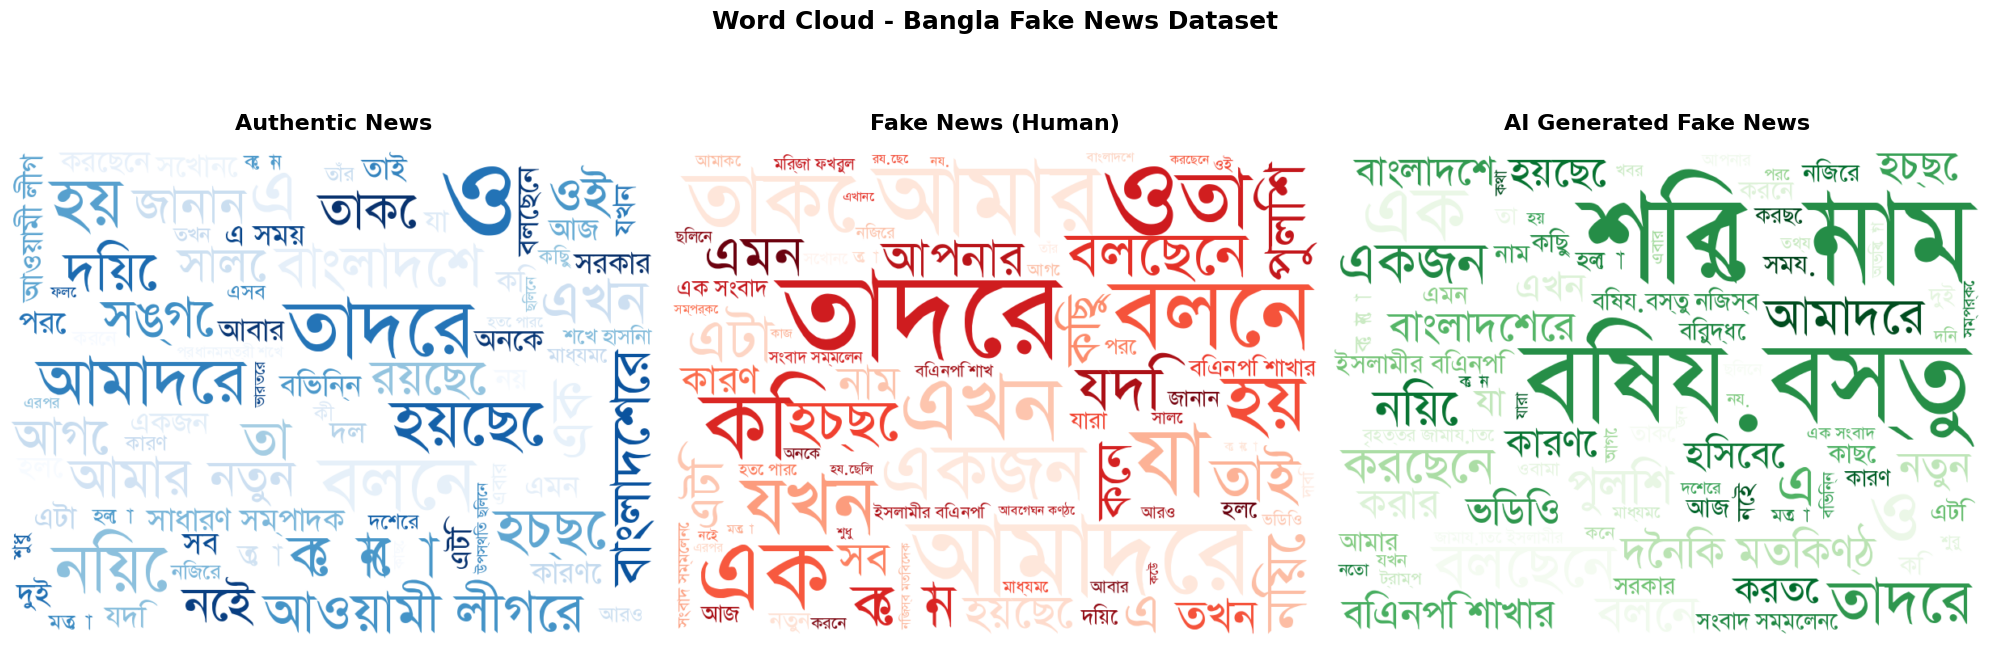

 Word Cloud v2 saved!


In [6]:
from wordcloud import STOPWORDS

# Bangla stopwords
bangla_stopwords = set([
    'এবং', 'বা', 'তবে', 'কিন্তু', 'যে', 'এই', 'সেই',
    'একটি', 'একটা', 'করা', 'হয়', 'হয়েছে', 'করেছে',
    'থেকে', 'পর', 'আর', 'তার', 'এর', 'কে', 'না',
    'হবে', 'ছিল', 'আছে', 'করে', 'যায়', 'দিয়ে',
    'জন্য', 'সাথে', 'মধ্যে', 'উপর', 'নিয়ে', 'বলে',
    'তিনি', 'তারা', 'আমরা', 'আমি', 'আপনি', 'সে'
])

# Updated Word Cloud
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

configs = [
    (authentic_text, 'Authentic News', 'Blues', axes[0]),
    (fake_text, 'Fake News (Human)', 'Reds', axes[1]),
    (ai_fake_text, 'AI Generated Fake News', 'Greens', axes[2]),
]

for text, title, cmap, ax in configs:
    wc = WordCloud(
        font_path=font_path,
        width=800,
        height=600,
        background_color='white',
        colormap=cmap,
        max_words=80,
        min_font_size=12,
        max_font_size=150,
        stopwords=bangla_stopwords,
        random_state=42,
        regexp=r'[\u0980-\u09FF]+',  # শুধু বাংলা শব্দ
    ).generate(text)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.axis('off')

plt.suptitle('Word Cloud - Bangla Fake News Dataset',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(
    'C:/Users/Riyad/projects/fake_news/word_cloud_v2.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
print(" Word Cloud v2 saved!")